In [2]:
#Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [3]:
df=pd.read_csv('factory_sensor_simulator_2040.csv')
conn=sqlite3.connect('factory_sensor_data.db')
df.to_sql('factory_sensor_simulator_2040',conn,index=False,if_exists='replace')
#name the table inside the database as 'factory_sensor_simulator_2040'


500000

In [4]:
conn=sqlite3.connect('factory_sensor_data.db')
query="""  
SELECT * 
FROM 'factory_sensor_simulator_2040' 
"""  
df=pd.read_sql(query,conn)
print(df.shape)
df.head()

(500000, 22)


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,1,3,162.0,0,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,1,4,147.0,0,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,1,6,0.0,1,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,0,4,161.0,0,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,0,1,765.0,0,NaN,NaN,NaN,NaN,0


In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  object 
 1   Machine_Type                500000 non-null  object 
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision

In [6]:

print(df.describe(),df.isnull().sum())#printing number of null values in each column

       Installation_Year  Operational_Hours  Temperature_C  Vibration_mms  \
count      500000.000000      500000.000000  500000.000000   500000.00000   
mean         2019.962360       50012.424764      59.997682        9.99114   
std            11.829812       28861.849078      14.986973        4.99953   
min          2000.000000           0.000000     -15.730000      -17.82000   
25%          2010.000000       25055.000000      49.890000        6.62000   
50%          2020.000000       49973.000000      60.000000       10.00000   
75%          2030.000000       74995.000000      70.050000       13.36000   
max          2040.000000      100000.000000     127.330000       32.47000   

            Sound_dB  Oil_Level_pct  Coolant_Level_pct  Power_Consumption_kW  \
count  500000.000000  500000.000000      500000.000000         500000.000000   
mean       75.003477      69.456568          64.114159            149.922161   
std         9.990791      18.847444          23.152998            

In [7]:
#Filling Null values with mean for numerical columns and mode for categorical columns
for column in df.columns:
    if df[column].dtype in ['float64', 'int64']:
        df[column]=df[column].fillna(df[column].mean())
   
print(df.isnull().sum())#checking if all null values are filled

Machine_ID                    0
Machine_Type                  0
Installation_Year             0
Operational_Hours             0
Temperature_C                 0
Vibration_mms                 0
Sound_dB                      0
Oil_Level_pct                 0
Coolant_Level_pct             0
Power_Consumption_kW          0
Last_Maintenance_Days_Ago     0
Maintenance_History_Count     0
Failure_History_Count         0
AI_Supervision                0
Error_Codes_Last_30_Days      0
Remaining_Useful_Life_days    0
Failure_Within_7_Days         0
Laser_Intensity               0
Hydraulic_Pressure_bar        0
Coolant_Flow_L_min            0
Heat_Index                    0
AI_Override_Events            0
dtype: int64


In [8]:
df.head()

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,1,3,162.0,0,74.995513,119.917514,39.984794,499.760966,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,1,4,147.0,0,74.995513,119.917514,40.920000,499.760966,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,1,6,0.0,1,74.995513,119.917514,39.984794,499.760966,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,0,4,161.0,0,74.995513,119.917514,39.984794,499.760966,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,0,1,765.0,0,74.995513,119.917514,39.984794,499.760966,0


In [9]:
int(((df["Installation_Year"]>2040) & (df["Failure_History_Count"]>0)).sum())
#No data is beyond 2040, so we can assume that the data is clean and ready for analysis

0

Failure_Within_7_Days         1.000000
Operational_Hours             0.396812
Vibration_mms                 0.037124
Temperature_C                 0.026189
Failure_History_Count         0.002033
Laser_Intensity               0.000406
AI_Supervision                0.000357
Last_Maintenance_Days_Ago     0.000299
Power_Consumption_kW          0.000071
Maintenance_History_Count    -0.000308
Oil_Level_pct                -0.000885
Error_Codes_Last_30_Days     -0.000911
Sound_dB                     -0.001354
Hydraulic_Pressure_bar       -0.001403
Heat_Index                   -0.001404
Coolant_Flow_L_min           -0.001800
Installation_Year            -0.001872
AI_Override_Events           -0.002043
Coolant_Level_pct            -0.002152
Remaining_Useful_Life_days   -0.395519
dtype: float64


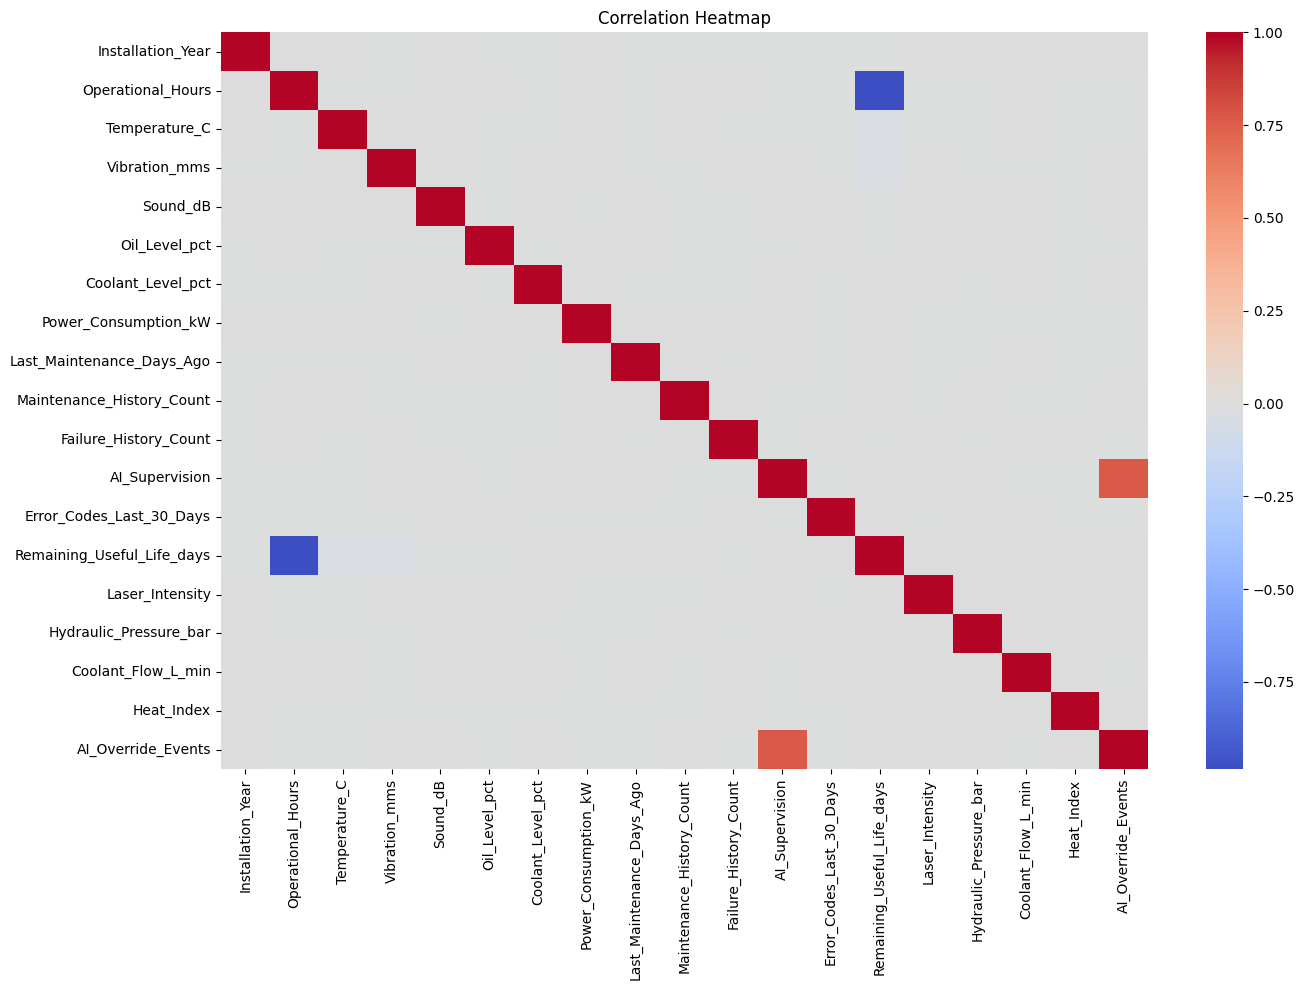

In [20]:
#Analyzing the correlation of each parameter with the target variable 'Failure_Within_7_Days'
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corrwith(numeric_df["Failure_Within_7_Days"]).sort_values(ascending=False)
print(correlation)

# Correlation heatmap for numeric features
num_features = df.select_dtypes(include=[np.number])
if "Failure_Within_7_Days" in num_features.columns:
    num_features = num_features.drop(columns=["Failure_Within_7_Days"])
plt.figure(figsize=(14, 10))
sns.heatmap(num_features.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


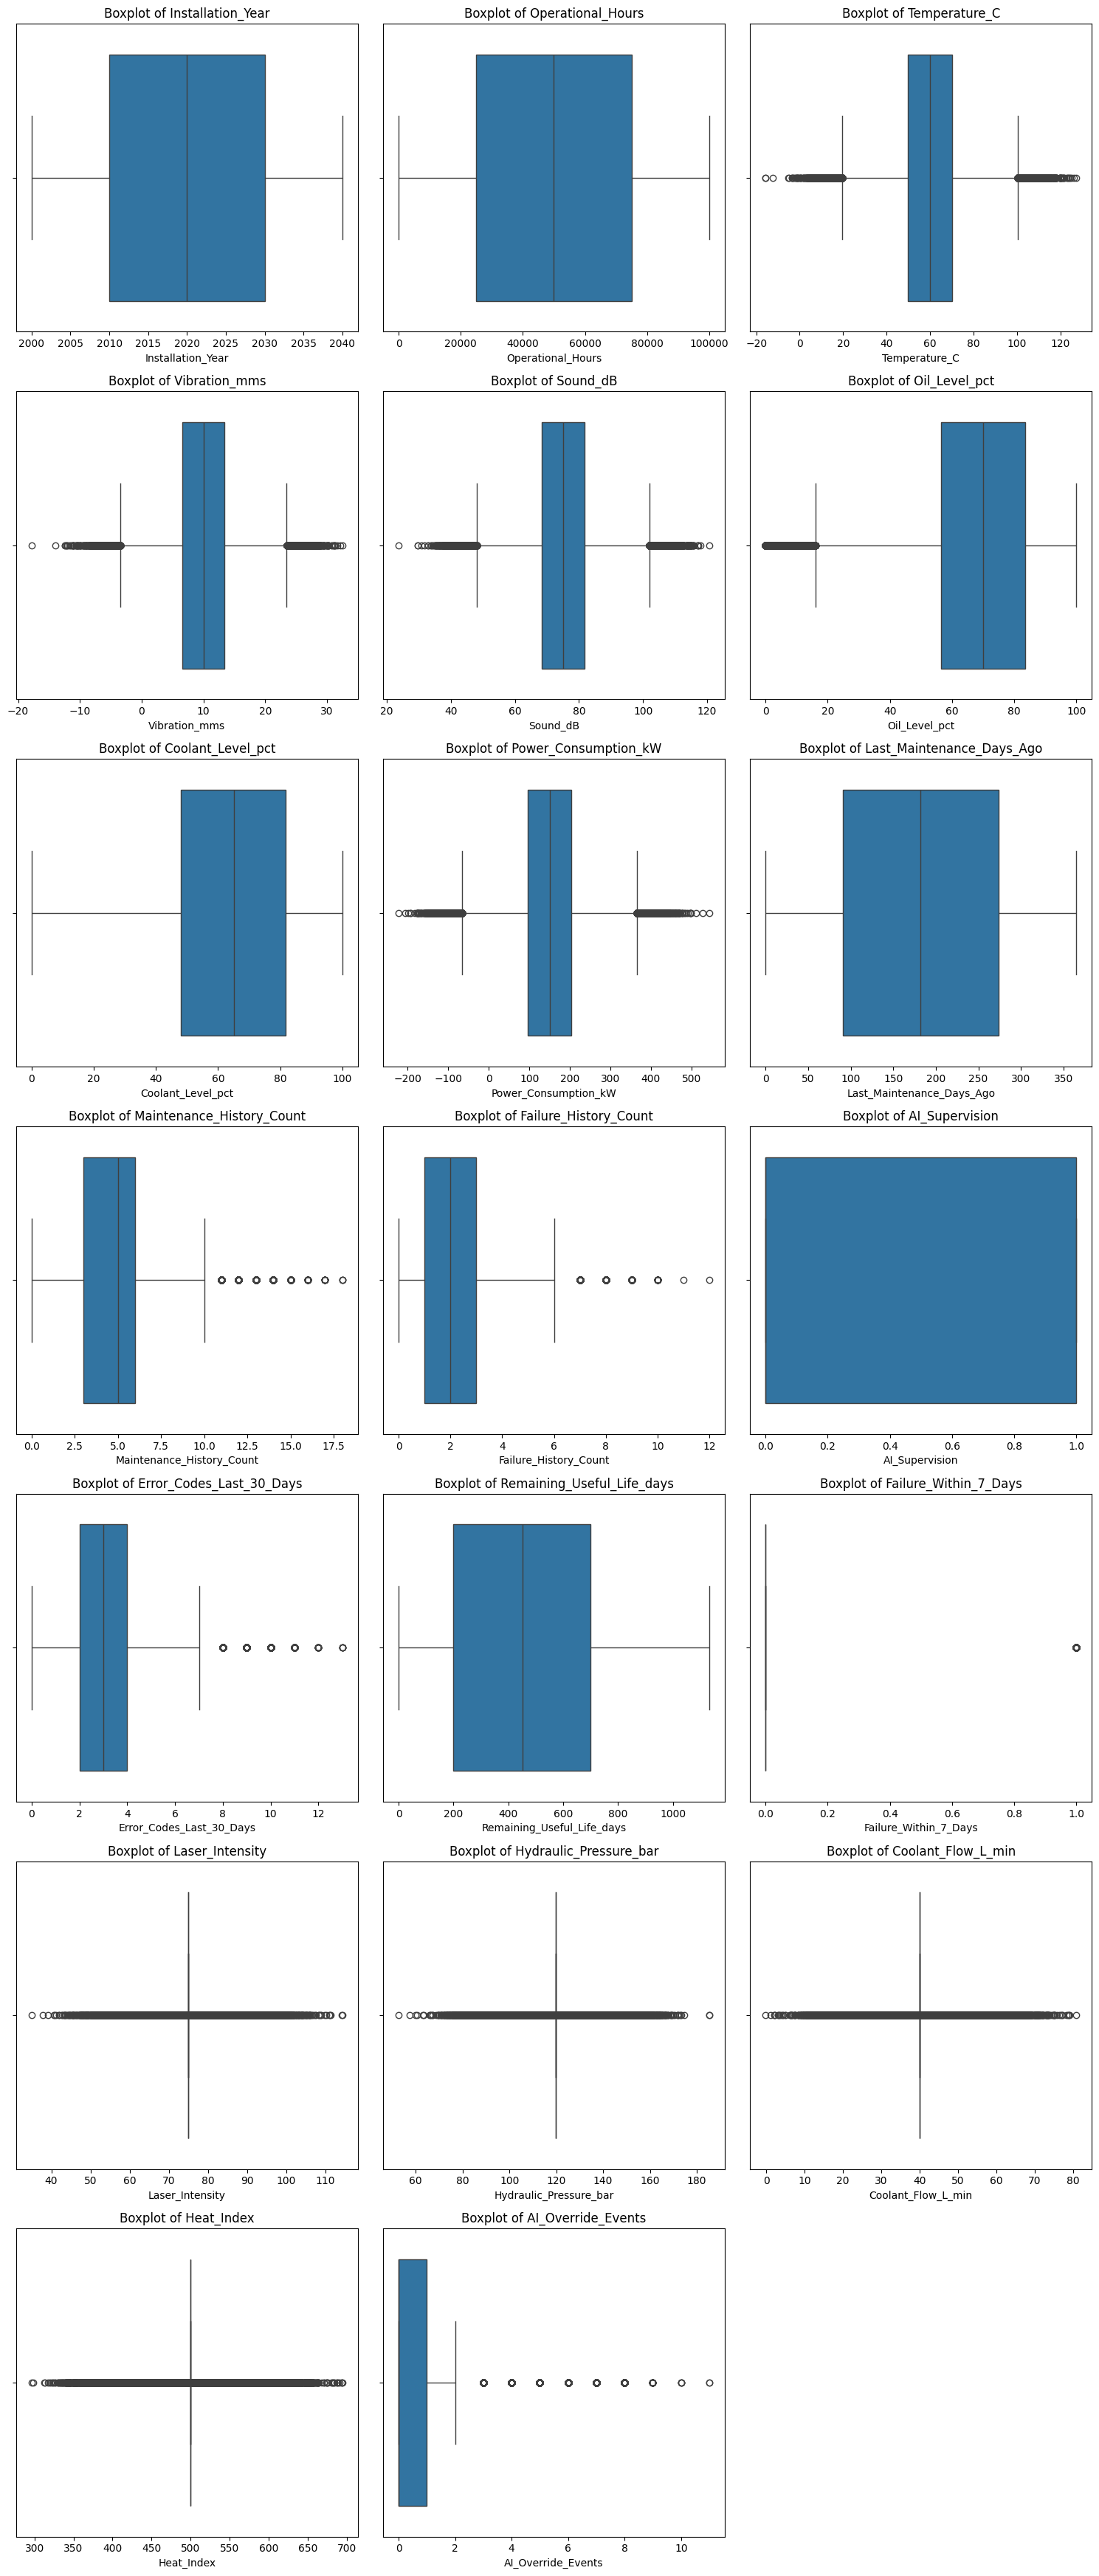

In [11]:
#Detecting outliers in the dataset using boxplot
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_df = df.select_dtypes(include=[np.number])

#to plot multiple boxplots in a grid layout
ncols = 3
nrows = math.ceil(len(numeric_df.columns) / ncols)   
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(x=numeric_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for ax in axes[len(numeric_df.columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


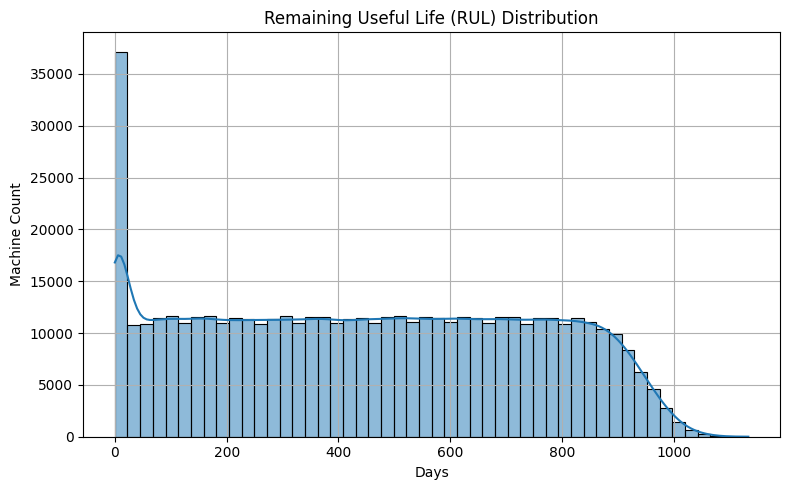

In [15]:
# Target distribution
#This plot shows the distribution of the target variable 'Remaining_Useful_Life_days' which indicates how many days are left before a machine is expected to fail. 
# The histogram with KDE (Kernel Density Estimate) helps us understand the overall distribution and identify any skewness or patterns in the data.
plt.figure(figsize=(8, 5))
sns.histplot(df["Remaining_Useful_Life_days"], bins=50, kde=True)
plt.title("Remaining Useful Life (RUL) Distribution")
plt.xlabel("Days")
plt.ylabel("Machine Count")
plt.grid(True)
plt.tight_layout()
plt.show()

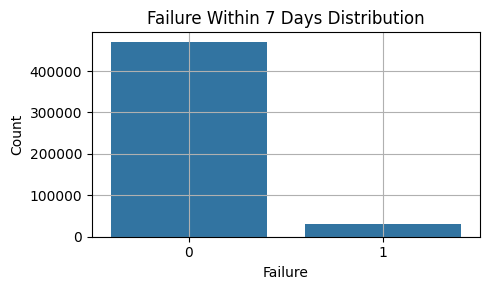

In [21]:
# Failure classification distribution
plt.figure(figsize=(5, 3))
sns.countplot(x="Failure_Within_7_Days", data=df)
plt.title("Failure Within 7 Days Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_features_grid(df, target_col="Failure_Within_7_Days", n_cols=3):

    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    numeric_cols = [col for col in numeric_cols if col != target_col]

    n_features = len(numeric_cols)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6*n_cols, 4*n_rows)
    )

    axes = np.array(axes).flatten()

    for i, feature in enumerate(numeric_cols):
        ax = axes[i]

        sns.kdeplot(
            df[df[target_col] == True][feature],
            label="Fail=True",
            fill=True,
            alpha=0.3,
            ax=ax
        )

        sns.kdeplot(
            df[df[target_col] == False][feature],
            label="Fail=False",
            fill=True,
            alpha=0.3,
            ax=ax
        )

        ax.set_title(feature)
        ax.legend()

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

Failure Analysis Summary 

The plots show clear behavioral differences between machines that failed within 7 days and those that did not.
Failures are concentrated at high operational hours and near-maximum oil/coolant levels.
Machines with frequent maintenance or more recent errors tend to fail sooner.
The Remaining Useful Life (RUL) drops sharply before failure.
These features can serve as strong predictive indicators of industrial failure.

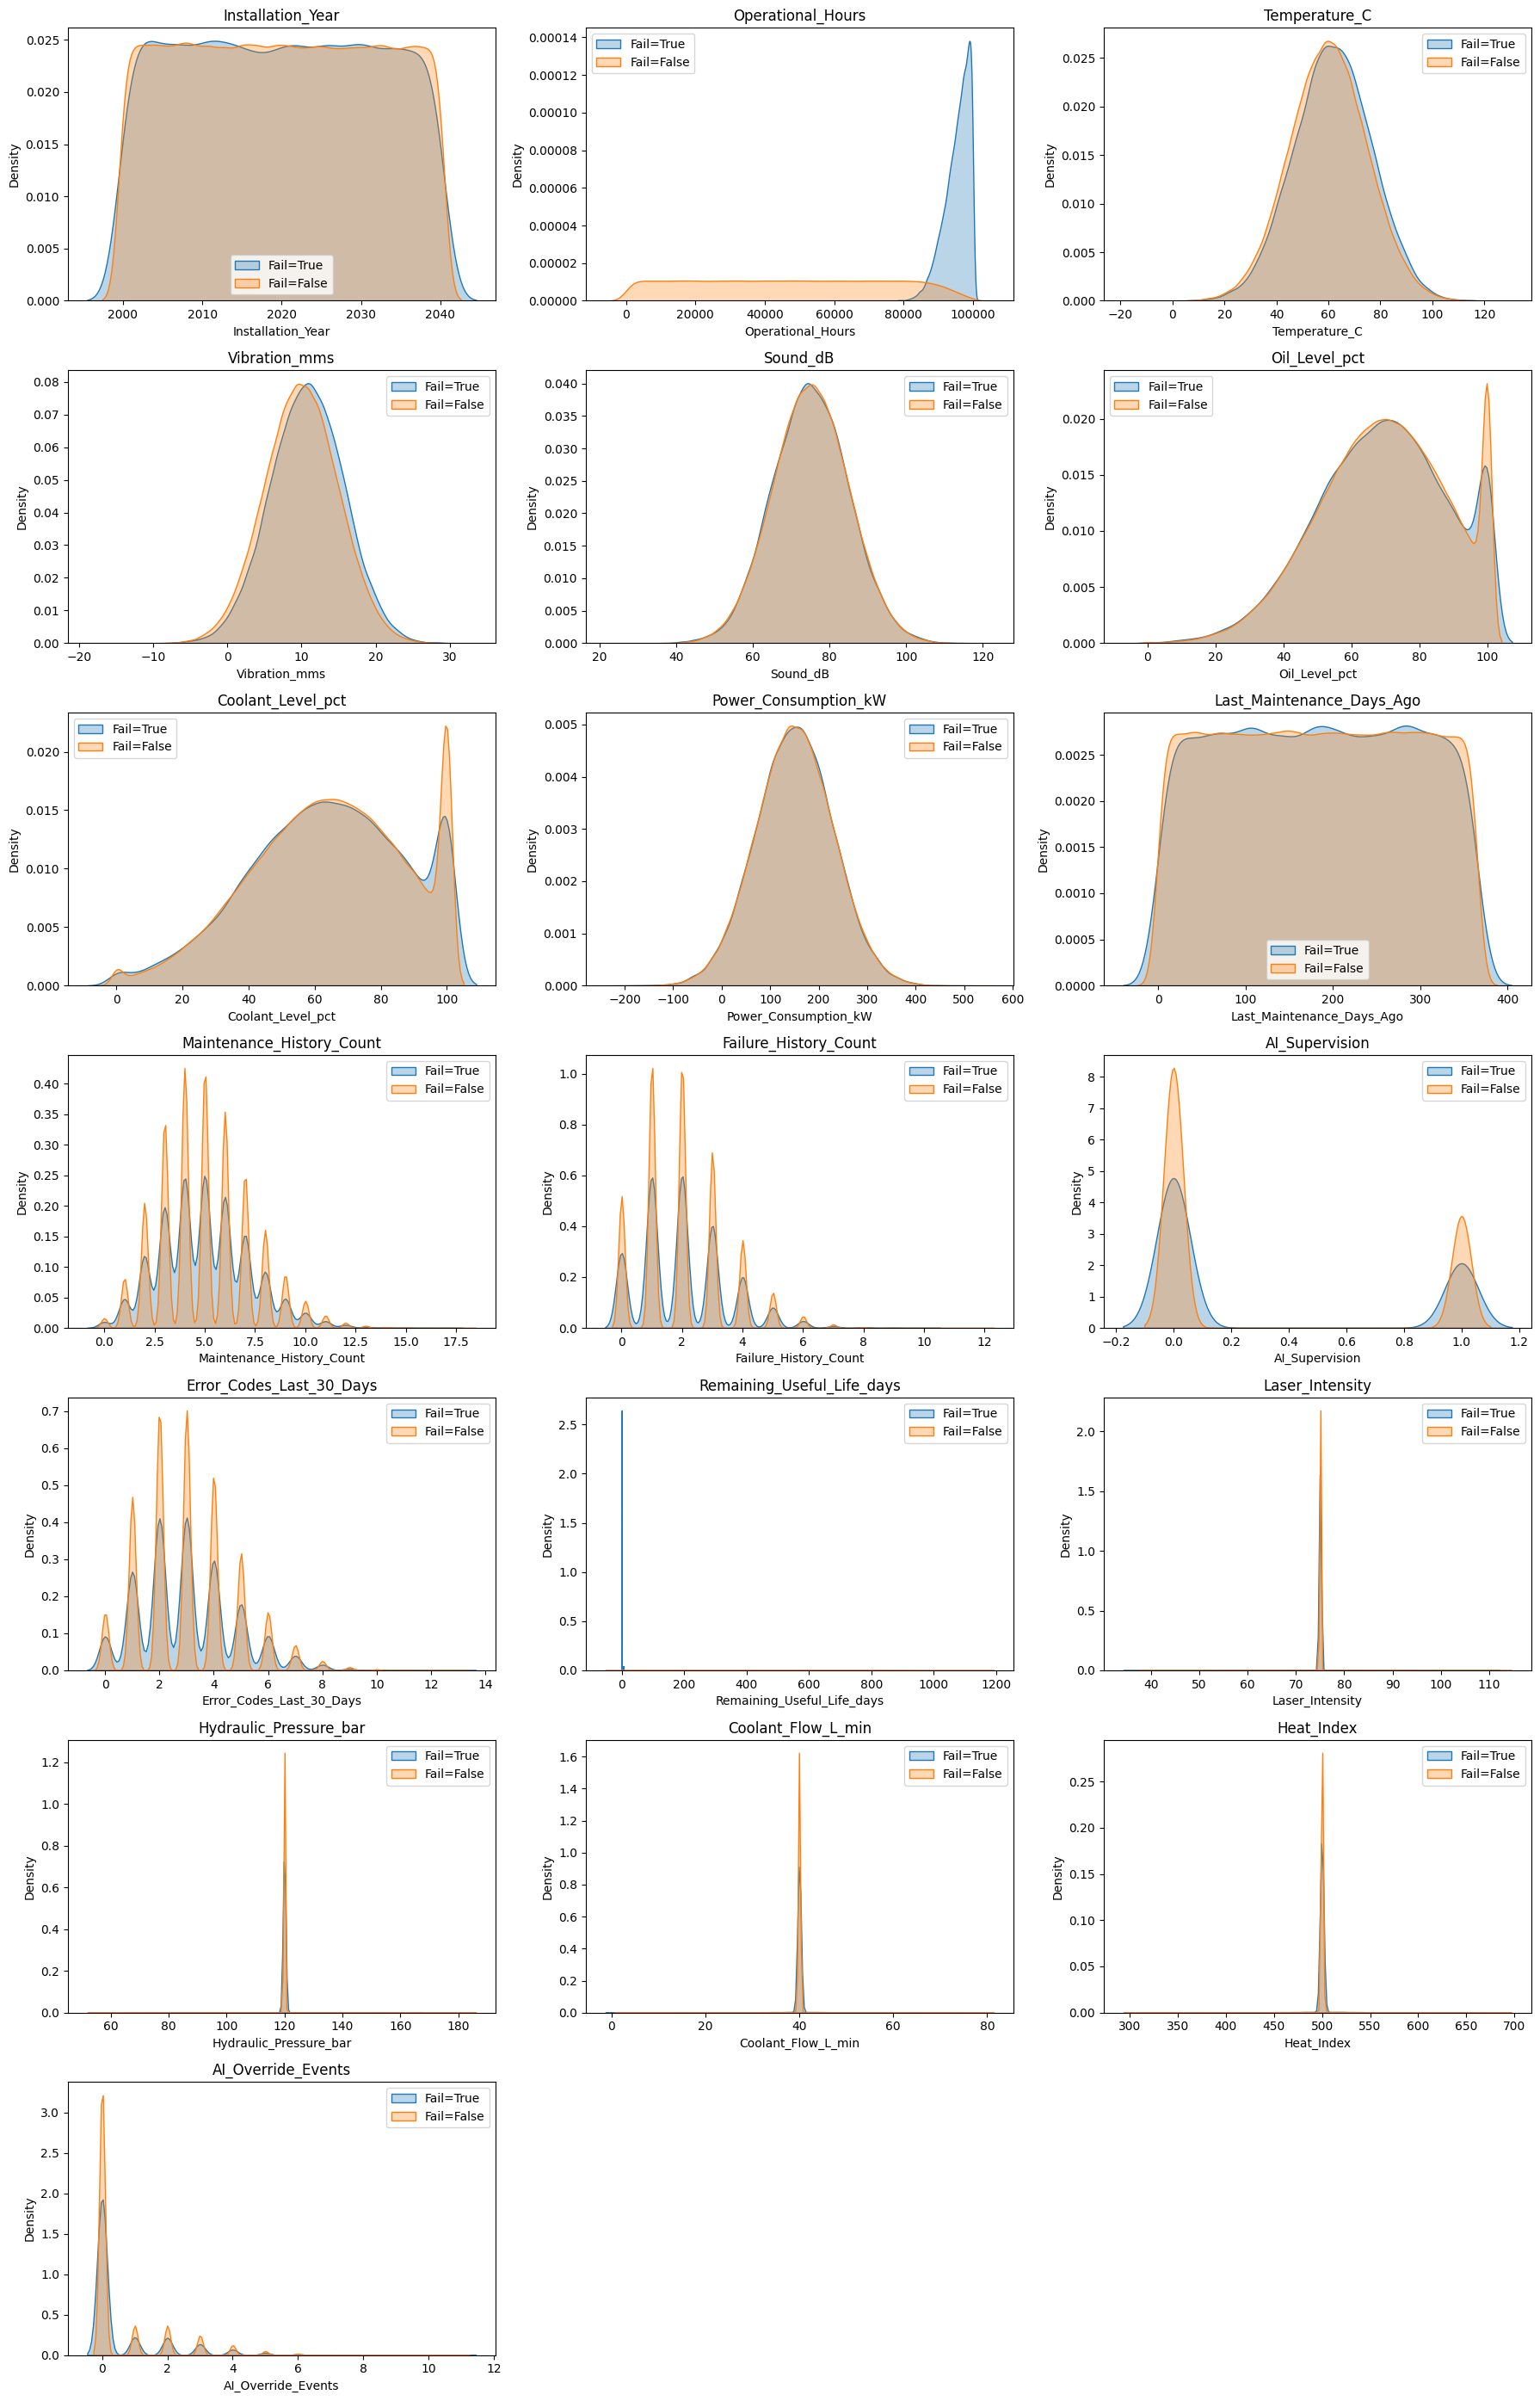

In [29]:
plot_all_features_grid(df)

<Axes: xlabel='Machine_Type'>

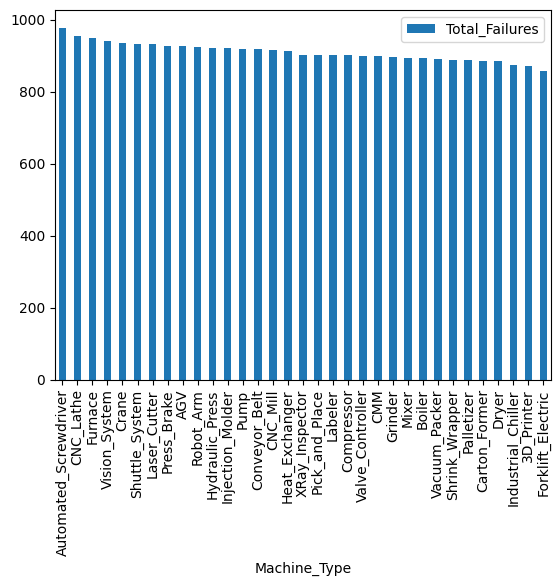

In [ ]:
#filtering machine type based on the target
target="""
SELECT Machine_Type,
COUNT(*) AS Total_Failures
FROM 'factory_sensor_simulator_2040'
WHERE Failure_Within_7_Days=1
GROUP BY Machine_Type
ORDER BY Total_Failures DESC
"""
df_target_by_machine_type=pd.read_sql(target,conn)

#Projecting failure rates in different types of machines 
df_target_by_machine_type.plot(kind='bar',x='Machine_Type',y='Total_Failures')




   Installation_Year  Total_Failures      Machine_Type
0               2032             903        Palletizer
1               2008             891     Vision_System
2               2008             878    Pick_and_Place
3               2005             876         Robot_Arm
4               2002             875  Valve_Controller


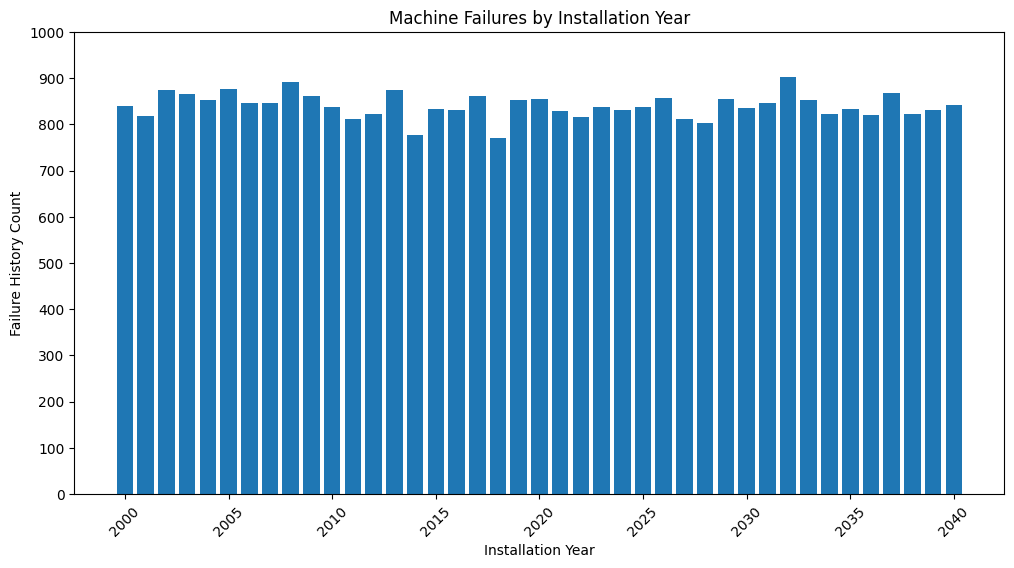

In [ ]:


query = """
SELECT Installation_Year,
       SUM(Failure_History_Count) AS Total_Failures,
       Machine_Type
FROM factory_sensor_simulator_2040
WHERE Failure_History_Count > 0
GROUP BY Installation_Year, Machine_Type
ORDER BY Total_Failures DESC
"""

df_failure_history_by_machine = pd.read_sql(query, conn)

# Preview
print(df_failure_history_by_machine.head())

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    df_failure_history_by_machine["Installation_Year"],
    df_failure_history_by_machine["Total_Failures"],
    width=0.8
)

plt.xlabel("Installation Year")
plt.ylabel("Failure History Count")
plt.title("Machine Failures by Installation Year")

max_failures = df_failure_history_by_machine["Total_Failures"].max()
plt.yticks(np.arange(0, max_failures + 100, 100))
plt.xticks(rotation=45)

plt.show()

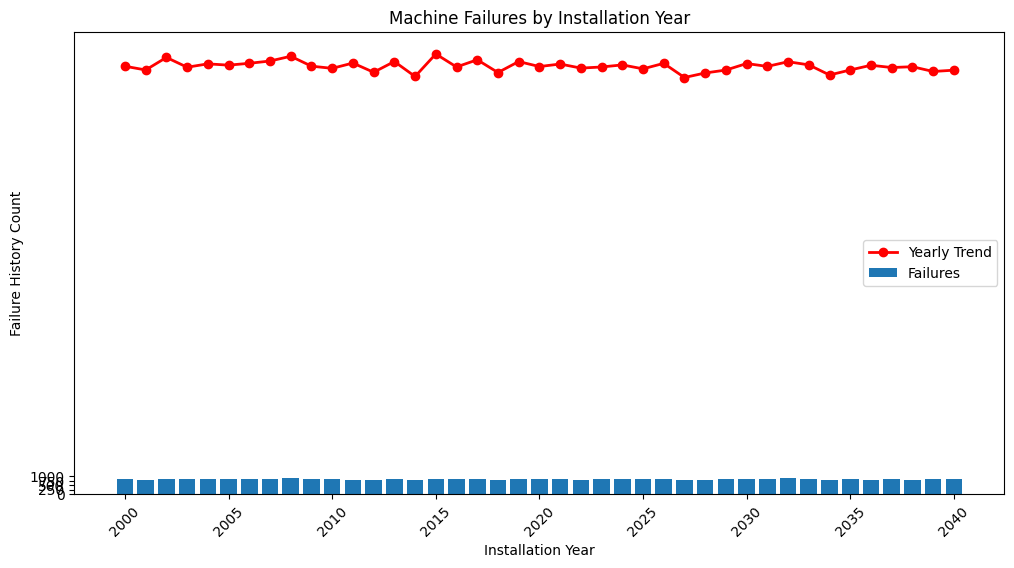

In [ ]:
# Plot
plt.figure(figsize=(12,6))
ax = plt.gca()

# Bar chart (per-row values)
ax.bar(
    df_failure_history_by_machine["Installation_Year"],
    df_failure_history_by_machine["Total_Failures"],
    width=0.8,
    label='Failures'
)

# Compute yearly totals and overlay a trend line
df_yearly = (
    df_failure_history_by_machine
    .groupby("Installation_Year")["Total_Failures"]
    .sum()
    .reset_index()
)
ax.plot(
    df_yearly["Installation_Year"],
    df_yearly["Total_Failures"],
    color='red', marker='o', linewidth=2, label='Yearly Trend'
)

ax.set_xlabel("Installation Year")
ax.set_ylabel("Failure History Count")
ax.set_title("Machine Failures by Installation Year")

max_failures = df_failure_history_by_machine["Total_Failures"].max()
ax.set_yticks(np.arange(0, max_failures + 250, 250))
plt.xticks(rotation=45)
ax.legend()

plt.show()
       

Mutual Information (MI) measures how much information a feature provides about the target variable.

In simple terms:

MI = 0 → The feature tells you nothing about the target.
Higher MI → Knowing the feature reduces uncertainty about the target.
MI detects both linear and non-linear relationships, unlike correlation which mainly measures linear relationships.

#SELECTING AND PLOTTING THE FEATURE IMPORTANCE OF TOP 9 FEATURES


In [30]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

target_col = "Failure_Within_7_Days"

# Numeric features only
X = df.select_dtypes(include=['int64','float64']).drop(columns=[target_col])
y = df[target_col]

# Compute mutual information
mi = mutual_info_classif(X, y, random_state=42)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi
}).sort_values("MI Score", ascending=False)

print(importance_df)

                       Feature  MI Score
13  Remaining_Useful_Life_days  0.227235
1            Operational_Hours  0.147798
15      Hydraulic_Pressure_bar  0.126664
17                  Heat_Index  0.116144
14             Laser_Intensity  0.102955
16          Coolant_Flow_L_min  0.074391
11              AI_Supervision  0.027114
10       Failure_History_Count  0.019641
12    Error_Codes_Last_30_Days  0.016457
9    Maintenance_History_Count  0.012365
18          AI_Override_Events  0.002520
0            Installation_Year  0.002287
6            Coolant_Level_pct  0.001270
5                Oil_Level_pct  0.000844
3                Vibration_mms  0.000635
2                Temperature_C  0.000391
7         Power_Consumption_kW  0.000000
4                     Sound_dB  0.000000
8    Last_Maintenance_Days_Ago  0.000000


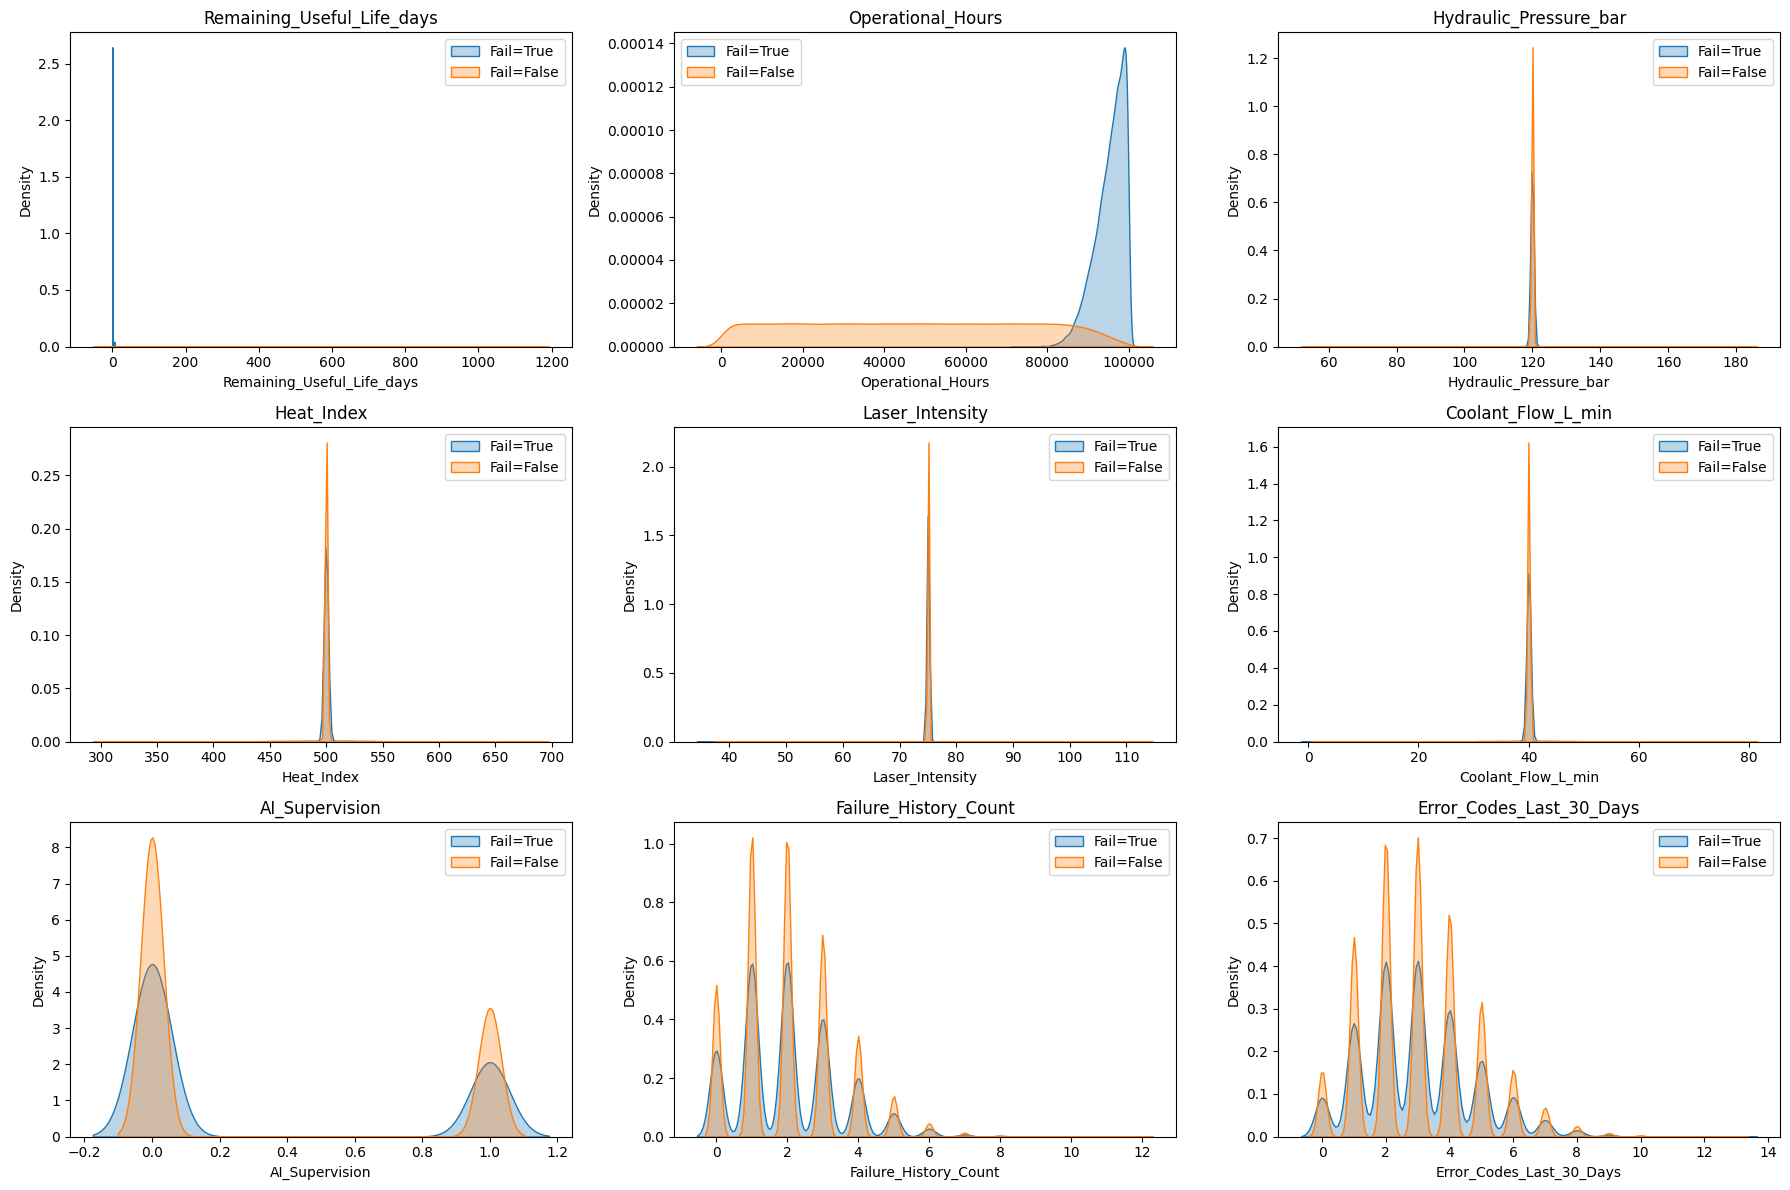

In [31]:
top_features = importance_df.head(9)["Feature"].tolist()

plot_df = df[top_features + [target_col]]
plot_all_features_grid(plot_df, target_col=target_col, n_cols=3)